In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier
from sklearn.metrics import r2_score,mean_squared_error,accuracy_score,confusion_matrix

LOAD DATASET

In [15]:
df = pd.read_csv("Waste_Management_with_Extra_Features.csv")
print(df.head())

  city/district    waste_type  waste_generated_(tons/day)  recycling_rate_(%)  \
0        Mumbai       Plastic                        6610                  68   
1        Mumbai       Organic                        1181                  56   
2        Mumbai       E-Waste                        8162                  53   
3        Mumbai  Construction                        8929                  56   
4        Mumbai     Hazardous                        5032                  44   

   population_density_(people/km²)  municipal_efficiency_score_(1_10)  \
0                            11191                                  9   
1                            11191                                  5   
2                            11191                                  8   
3                            11191                                  5   
4                            11191                                  7   

  disposal_method  cost_of_waste_management_(₹/ton)  \
0      Composting  

DATA PREPROCESSING


In [16]:
df = df.fillna(df.mean(numeric_only = True))#Handle missing values
label_enc = LabelEncoder()
df['city/district'] = label_enc.fit_transform(df['city/district'])
df['waste_type'] = label_enc.fit_transform(df['waste_type'])
df['disposal_method'] = label_enc.fit_transform(df['disposal_method'])

EXPLORATORY DATA ANALYSIS (EDA)

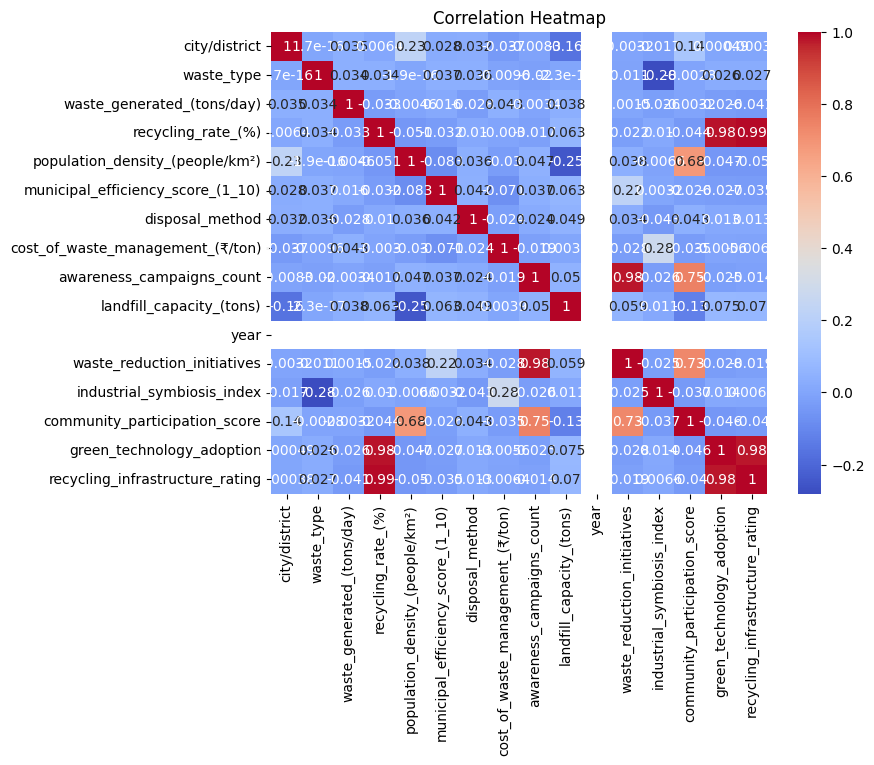

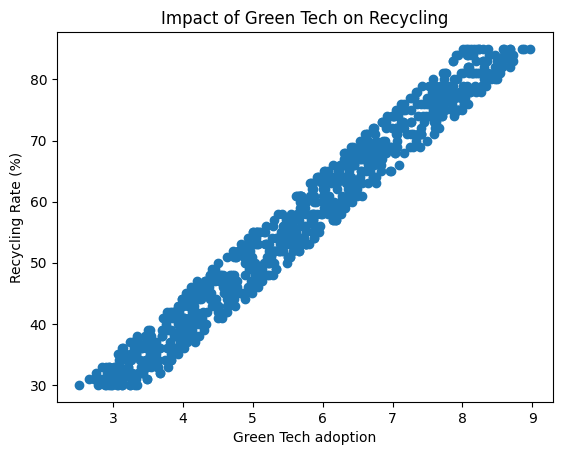

In [17]:
plt.figure(figsize=(8,6))
numeric_df = df.select_dtypes(include ='number')
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

plt.scatter(df['green_technology_adoption'],df['recycling_rate_(%)'])
plt.xlabel("Green Tech adoption")
plt.ylabel("Recycling Rate (%)")
plt.title("Impact of Green Tech on Recycling")
plt.show()#example : Recycling rate vs Green Tech Adoption




In [18]:
print(df.columns.tolist())
print(df.dtypes)

['city/district', 'waste_type', 'waste_generated_(tons/day)', 'recycling_rate_(%)', 'population_density_(people/km²)', 'municipal_efficiency_score_(1_10)', 'disposal_method', 'cost_of_waste_management_(₹/ton)', 'awareness_campaigns_count', 'landfill_name', 'landfill_location_(lat,_long)', 'landfill_capacity_(tons)', 'year', 'waste_reduction_initiatives', 'industrial_symbiosis_index', 'community_participation_score', 'green_technology_adoption', 'recycling_infrastructure_rating']
city/district                          int64
waste_type                             int64
waste_generated_(tons/day)             int64
recycling_rate_(%)                     int64
population_density_(people/km²)        int64
municipal_efficiency_score_(1_10)      int64
disposal_method                        int64
cost_of_waste_management_(₹/ton)       int64
awareness_campaigns_count              int64
landfill_name                         object
landfill_location_(lat,_long)         object
landfill_capacity_(to

REGRESSION MODEL(PREDICT COST)

In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

print("Columns in dataset:", df.columns.tolist())


X = df.drop(['cost_of_waste_management_(₹/ton)'], axis=1)
y = df['cost_of_waste_management_(₹/ton)']


X = pd.get_dummies(X)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


reg_model = RandomForestRegressor(n_estimators=100, random_state=42)
reg_model.fit(X_train, y_train)


y_pred = reg_model.predict(X_test)


print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))


feature_importances = pd.DataFrame(reg_model.feature_importances_,
                                   index=X.columns,
                                   columns=['Importance']).sort_values('Importance', ascending=False)
print(feature_importances)



Columns in dataset: ['city/district', 'waste_type', 'waste_generated_(tons/day)', 'recycling_rate_(%)', 'population_density_(people/km²)', 'municipal_efficiency_score_(1_10)', 'disposal_method', 'cost_of_waste_management_(₹/ton)', 'awareness_campaigns_count', 'landfill_name', 'landfill_location_(lat,_long)', 'landfill_capacity_(tons)', 'year', 'waste_reduction_initiatives', 'industrial_symbiosis_index', 'community_participation_score', 'green_technology_adoption', 'recycling_infrastructure_rating']
R2 Score: 0.0023965362985677308
MSE: 1617986.4276676471
                                                Importance
industrial_symbiosis_index                        0.317321
waste_generated_(tons/day)                        0.072961
waste_reduction_initiatives                       0.065674
community_participation_score                     0.063771
green_technology_adoption                         0.057288
...                                                    ...
landfill_location_(lat,_lon

CLASSIFICATION MODEL(PREDICT DISPOSAL METHOD)

In [20]:
X = df.drop(['disposal_method'], axis=1)
y = df['disposal_method']


X = pd.get_dummies(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


clf_model = RandomForestClassifier(n_estimators=100, random_state=42)
clf_model.fit(X_train, y_train)


y_pred = clf_model.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))



Accuracy: 0.21764705882352942
Confusion Matrix:
 [[ 5 16 10 13]
 [ 9 11 16  5]
 [ 9 10 12  8]
 [13 10 14  9]]


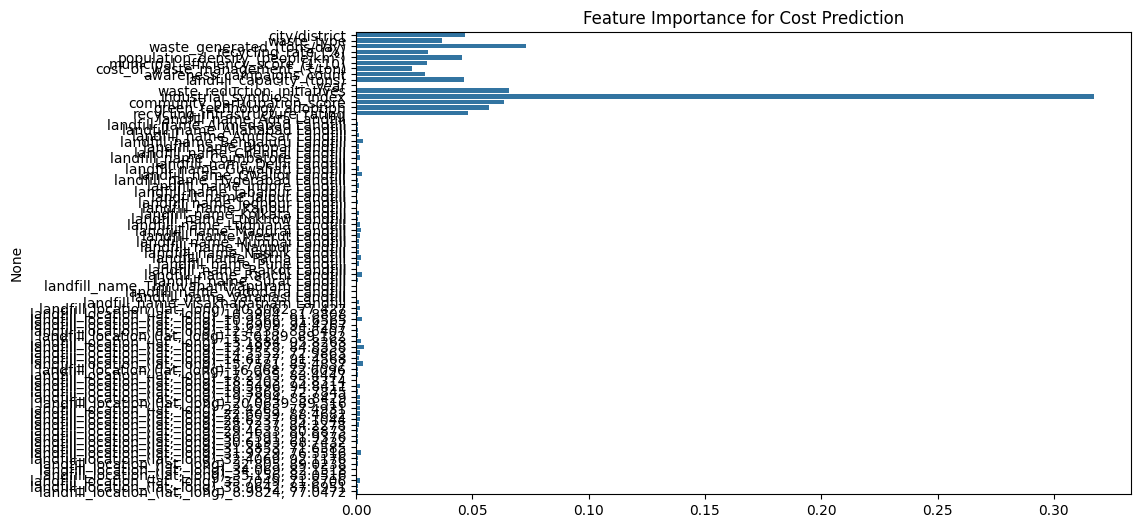

In [21]:
importances = reg_model.feature_importances_
features = X.columns

plt.figure(figsize=(10,6))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance for Cost Prediction")
plt.show()
